In [24]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [25]:
# create a pure dataset

np.random.seed(42)
n = 1000

# --- Features ---
age = np.random.randint(22, 65, n)

education = np.random.choice(
    ['High School', 'Bachelor', 'Master', 'PhD'],
    n, p=[0.35, 0.40, 0.18, 0.07]
)

# assuming people start working at the age of 22
# the experience could be 40-90% accurate
# adding noise, clipping the overall experience to be between 0 and 40 yrs
experience = np.clip((age - 22) * np.random.uniform(0.4, 0.9, n) + np.random.normal(0, 2, n),0, 40).astype(int)

education_base = {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}
edu_score  = np.array([education_base[e] for e in education])

# Income depends on Education + Experience, equal weightage
income_score = edu_score * 0.5 + (experience / 10) * 0.5 + np.random.normal(0, 0.5, n)

income = np.select(
    [income_score < 1.0, income_score < 2.0, income_score >= 2.0],
    ['Low','Medium','High'],
    default=''
)

df = pd.DataFrame({
    'Age':        age,
    'Education':  education,
    'Experience': experience,
    'Income':     income        # target
})

In [26]:
df

,Age,Education,Experience,Income
0,60,Bachelor,26,Medium
1,50,Master,25,High
2,36,High School,11,Low
3,64,Bachelor,35,High
4,29,Bachelor,4,Low
...,...,...,...,...
995,54,High School,22,High
996,25,High School,0,Low
997,43,High School,6,Low
998,23,Master,2,Medium


In [27]:
perc_missing = round(n * 0.2)
missing_idx  = np.random.choice(n, perc_missing, replace=False)

df_mcar = df.copy()
df_mcar.iloc[missing_idx, df_mcar.columns.get_loc('Income')] = np.nan

print(f"Missing values: {df_mcar['Income'].isna().sum()} ({perc_missing/n:.0%})")

Missing values: 200 (20%)


In [28]:
# shared features used by all model-based methods
FEATURES  = ['Age', 'Education_enc', 'Experience']
TARGET    = 'Income'

# encoding means converting categorical value into numerical
def encode_education(df_res):
    le_edu = LabelEncoder()
    df_res['Education_enc'] = le_edu.fit_transform(df_res['Education'])
    return df_res

# encode income values which are not na
def encode_income(df_res, target_col=TARGET):
    le_inc = LabelEncoder()
    known_mask = df_res[target_col].notna()
    df_res.loc[known_mask, 'Income_enc'] = le_inc.fit_transform(
                                            df_res.loc[known_mask, target_col])
    return df_res, le_inc, known_mask

def decode_and_return(df_res, le_inc, pred_enc, missing_mask, target_col=TARGET):
    pred_enc = np.clip(np.round(pred_enc).astype(int), 0, len(le_inc.classes_) - 1)
    df_res.loc[missing_mask, target_col] = le_inc.inverse_transform(pred_enc)
    return df_res[['Age', 'Education', 'Experience', target_col]]

def mode_imputation(df_miss, target_col=TARGET):
    df_res = df_miss.copy()
    mode_val = df_res[target_col].mode()[0]
    df_res[target_col] = df_res[target_col].fillna(mode_val)
    return df_res

# unline the mode of the whole dataset, this finds the mode of particular category and fills the missing value
def grouped_mode_imputation(df_miss, target_col=TARGET):
    df_res = df_miss.copy()
    group_mode = df_res.groupby('Education')[target_col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.mode())
    )
    df_res[target_col] = df_res[target_col].fillna(group_mode)
    return df_res

def knn_imputation(df_miss, k=5, target_col=TARGET):
    df_res = df_miss.copy()
    df_res = encode_education(df_res)
    df_res, le_inc, _ = encode_income(df_res, target_col)
    
    imputer = KNNImputer(n_neighbors=k)
    # fit_transform returns a plain numpy array, ALL NaNs filled
    imputed_array = imputer.fit_transform(df_res[['Age', 'Education_enc', 'Experience', 'Income_enc']])

    # extract only the income column
    # round back to valid class indices, minimum and maximum numbers being 0 and len(le_inc.classes_) - 1    
    income_enc_imputed = np.clip(
        np.round(imputed_array[:, 3]).astype(int),
        0, len(le_inc.classes_) - 1
    )
    
    # decode back to the income classes    
    df_res[target_col] = le_inc.inverse_transform(income_enc_imputed)    
    return df_res[['Age', 'Education', 'Experience', target_col]]

def logistic_regression_imputation(df_miss, target_col=TARGET):
    df_res = df_miss.copy()
    df_res = encode_education(df_res)
    
    known_mask = df_res[target_col].notna()
    X_train = df_res.loc[known_mask,  FEATURES]
    y_train = df_res.loc[known_mask,  target_col]
    X_pred  = df_res.loc[~known_mask, FEATURES]
    
    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(X_train, y_train)
    df_res.loc[~known_mask, target_col] = clf.predict(X_pred)
    
    return df_res[['Age', 'Education', 'Experience', target_col]]
    
def rf_classifier_imputation(df_miss, target_col=TARGET):
    df_res = df_miss.copy()
    df_res = encode_education(df_res)
    
    known_mask = df_res[target_col].notna()
    X_train = df_res.loc[known_mask,  FEATURES]
    y_train = df_res.loc[known_mask,  target_col]
    X_pred  = df_res.loc[~known_mask, FEATURES]
    
    clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
    clf.fit(X_train, y_train)
    df_res.loc[~known_mask, target_col] = clf.predict(X_pred)
    
    return df_res[['Age', 'Education', 'Experience', target_col]]

# gradient boosting 
def gb_classifier_imputation(df_miss, target_col=TARGET):
    df_res = df_miss.copy()
    df_res = encode_education(df_res)
    
    known_mask = df_res[target_col].notna()
    X_train = df_res.loc[known_mask,  FEATURES]
    y_train = df_res.loc[known_mask,  target_col]
    X_pred  = df_res.loc[~known_mask, FEATURES]
    
    clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                      max_depth=4, random_state=42)
    clf.fit(X_train, y_train)
    df_res.loc[~known_mask, target_col] = clf.predict(X_pred)
    
    return df_res[['Age', 'Education', 'Experience', target_col]]

# MICE with Random Forest
def mice_classifier_imputation(df_miss, target_col=TARGET):
    df_res = df_miss.copy()
    df_res = encode_education(df_res)
    df_res, le_inc, _ = encode_income(df_res, target_col)
    
    numeric_df = df_res[['Age', 'Education_enc', 'Experience', 'Income_enc']].copy()
    
    mice = IterativeImputer(
        estimator=RandomForestClassifier(n_estimators=50, random_state=42),
        max_iter=10, random_state=42, initial_strategy='most_frequent'
    )
    imputed_arr = mice.fit_transform(numeric_df)
    
    income_enc_imputed = np.clip(
        np.round(imputed_arr[:, 3]).astype(int),
        0, len(le_inc.classes_) - 1
    )
    df_res[target_col] = le_inc.inverse_transform(income_enc_imputed)
    return df_res[['Age', 'Education', 'Experience', target_col]]

In [29]:
def evaluate_categorical_imputations(df_true, df_missing, target_col=TARGET):
    missing_mask = df_missing[target_col].isna()
    missing_idx  = df_missing.index[missing_mask]
    y_true = df_true.loc[missing_idx, target_col]
    
    methods = {
        'Mode':               mode_imputation(df_missing),
        'Grouped Mode':       grouped_mode_imputation(df_missing),
        'KNN (k=5)':          knn_imputation(df_missing, k=5),
        'Logistic Regression':logistic_regression_imputation(df_missing),
        'Random Forest':      rf_classifier_imputation(df_missing),
        'Gradient Boosting':  gb_classifier_imputation(df_missing),
        'MICE (RF)':          mice_classifier_imputation(df_missing),
    }
    
    results = []
    confusion_matrices = {}
    
    for name, df_imputed in methods.items():
        y_pred = df_imputed.loc[missing_idx, target_col]
        acc = accuracy_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, average='weighted')
        cm  = confusion_matrix(y_true, y_pred, labels=['Low', 'Medium', 'High'])
        results.append({'Method': name, 'Accuracy': acc, 'F1 (weighted)': f1})
        confusion_matrices[name] = cm
    
    results_df = pd.DataFrame(results).sort_values('F1 (weighted)', ascending=False)
    return results_df, confusion_matrices

results_df, confusion_matrices = evaluate_categorical_imputations(df, df_mcar)
print("\n=== MCAR Performance Ranking ===")
print(results_df.round(4).to_string(index=False))


=== MCAR Performance Ranking ===
             Method  Accuracy  F1 (weighted)
      Random Forest     0.715         0.7153
  Gradient Boosting     0.700         0.6999
          MICE (RF)     0.655         0.6545
       Grouped Mode     0.645         0.6436
Logistic Regression     0.605         0.6042
          KNN (k=5)     0.495         0.4497
               Mode     0.425         0.2535


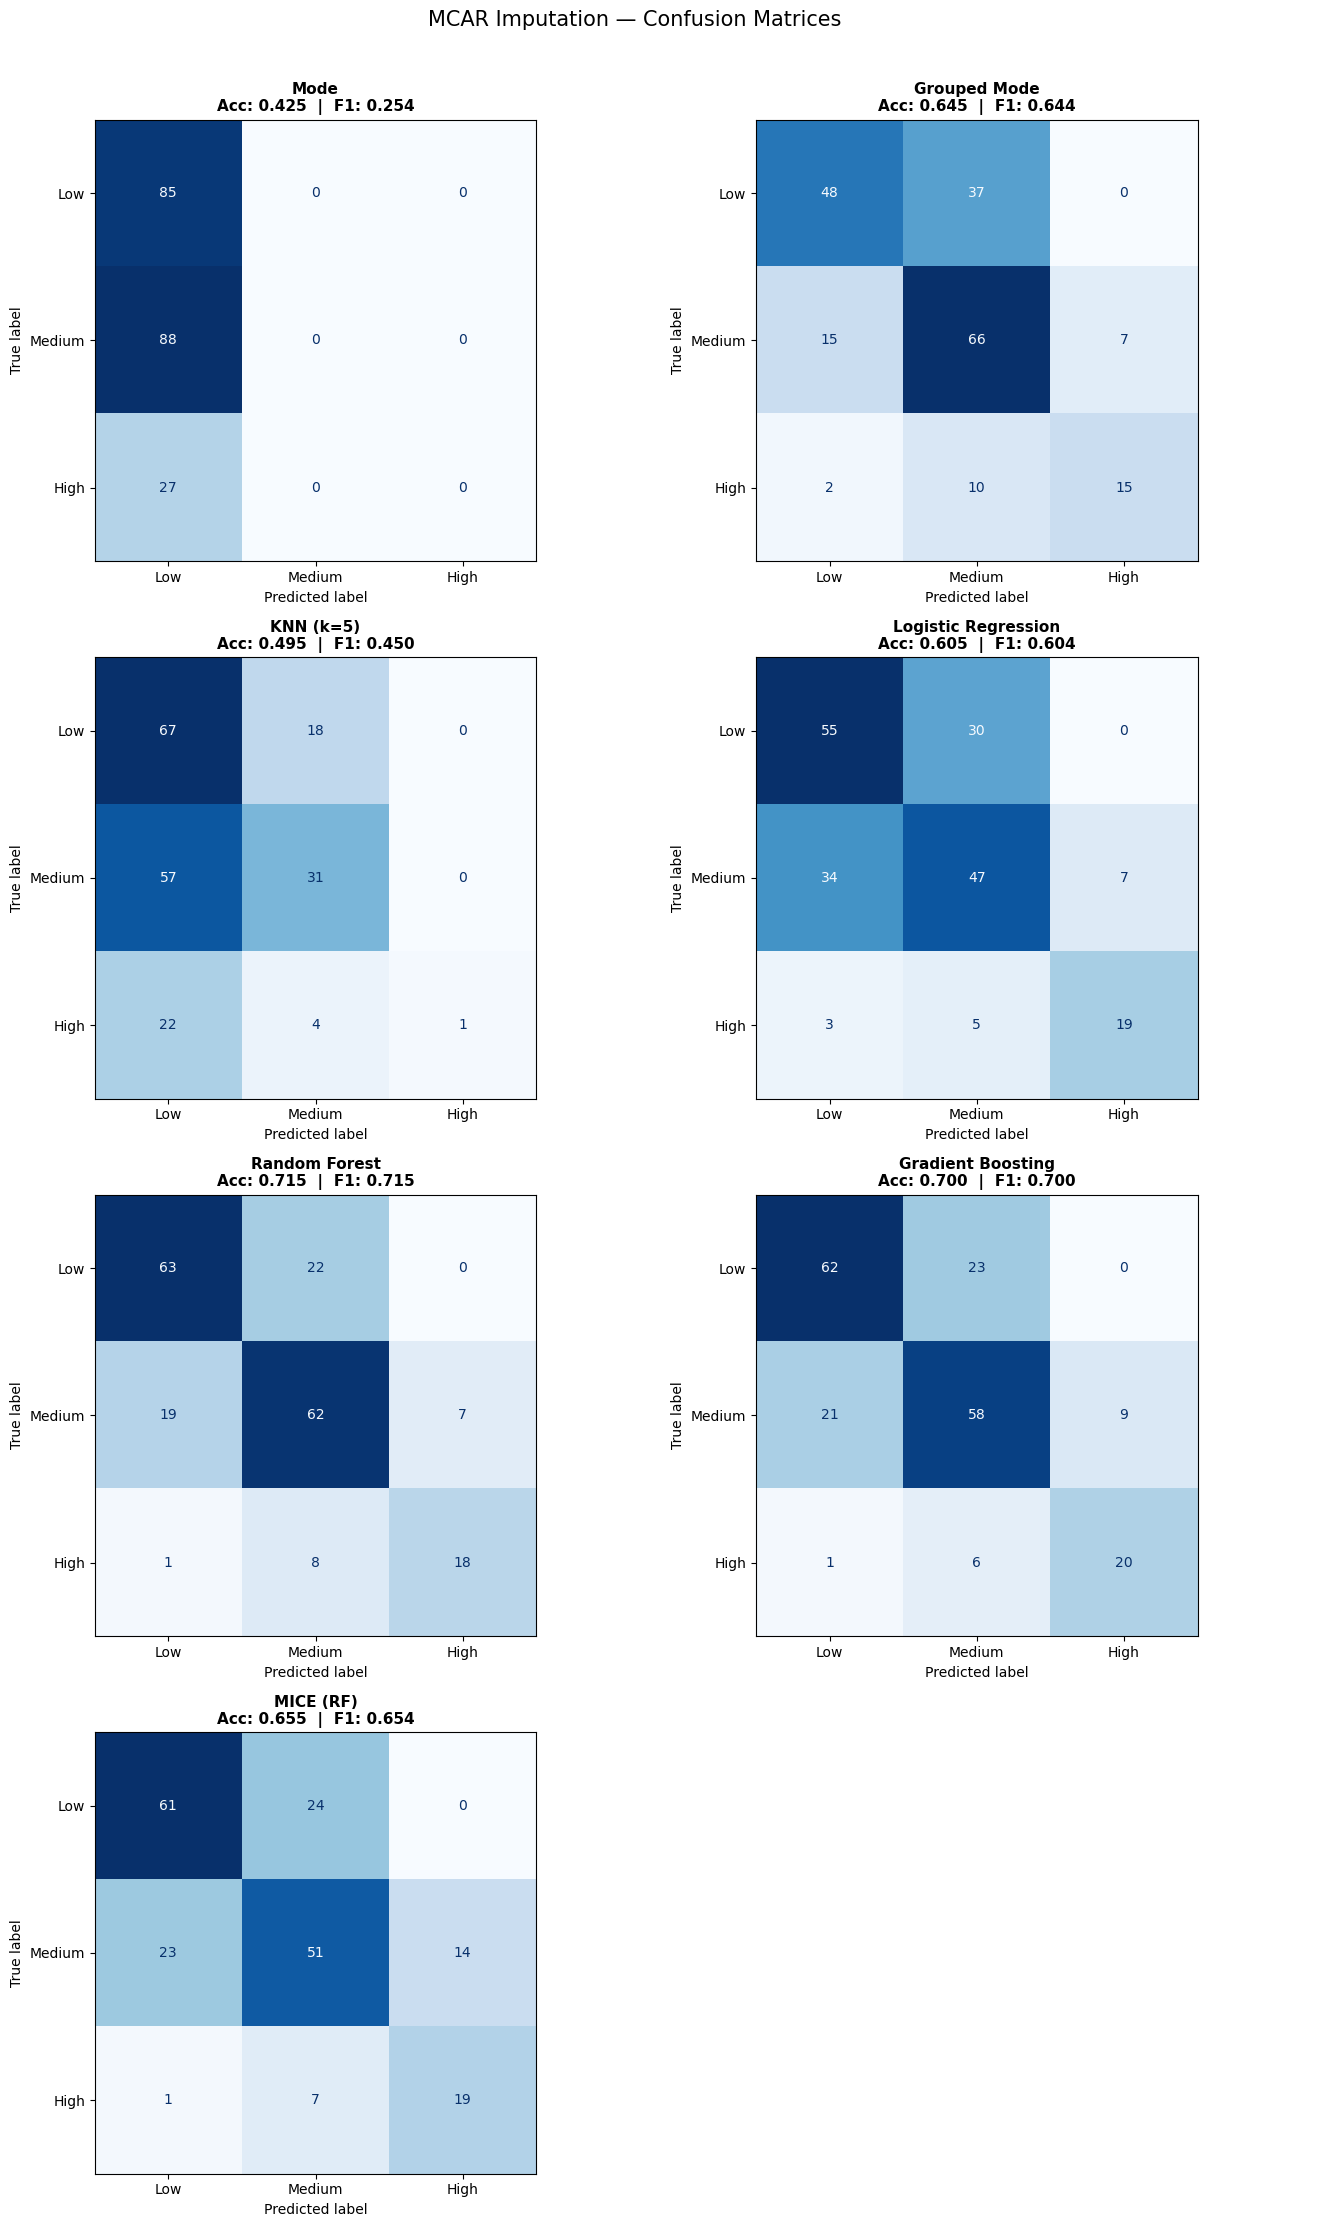

In [31]:
fig, axes = plt.subplots(4, 2, figsize=(14, 22))
axes = axes.flatten()
labels = ['Low', 'Medium', 'High']

for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    
    row = results_df[results_df['Method'] == name].iloc[0]
    ax.set_title(f"{name}\nAcc: {row['Accuracy']:.3f}  |  F1: {row['F1 (weighted)']:.3f}",
                 fontsize=11, fontweight='bold')

axes[-1].axis('off')   # hide the empty 8th subplot
plt.suptitle('MCAR Imputation — Confusion Matrices', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [32]:
"""
MAR
"""
# MAR — missingness depends on Age (observed column)
# older employees less likely to report income
# probability of missing ranges from 5% (youngest) to 35% (oldest)

age_normalized = (df['Age'] - df['Age'].min()) / (df['Age'].max() - df['Age'].min())
mar_missing_probs = 0.05 + 0.30 * age_normalized

mar_mask = np.random.binomial(1, mar_missing_probs).astype(bool)

df_mar = df.copy()
df_mar.loc[mar_mask, 'Income'] = np.nan

print(f"Total missing: {df_mar['Income'].isna().sum()} ({mar_mask.mean():.0%})")

# verify — older age buckets should have more missing
df['age_bucket'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 65], 
                           labels=['20s', '30s', '40s', '50s+'])
df_mar['age_bucket'] = df['age_bucket']

print("\nMissing rate by age bucket — should increase with age:")
print(
    df_mar.groupby('age_bucket', observed=True)['Income']
    .apply(lambda x: x.isna().mean())
    .round(3)
)

# clean up helper column
df_mar  = df_mar.drop(columns='age_bucket')

Total missing: 205 (20%)

Missing rate by age bucket — should increase with age:
age_bucket
20s     0.056
30s     0.179
40s     0.200
50s+    0.322
Name: Income, dtype: float64


In [33]:
results_mar, confusion_matrices_mar = evaluate_categorical_imputations(df, df_mar)

print("\n=== MAR Performance Ranking ===")
print(results_mar.round(4).to_string(index=False))


=== MAR Performance Ranking ===
             Method  Accuracy  F1 (weighted)
  Gradient Boosting    0.6537         0.6535
      Random Forest    0.6341         0.6265
          MICE (RF)    0.6195         0.6193
Logistic Regression    0.6146         0.6099
       Grouped Mode    0.5707         0.5510
          KNN (k=5)    0.4146         0.3946
               Mode    0.3220         0.1568


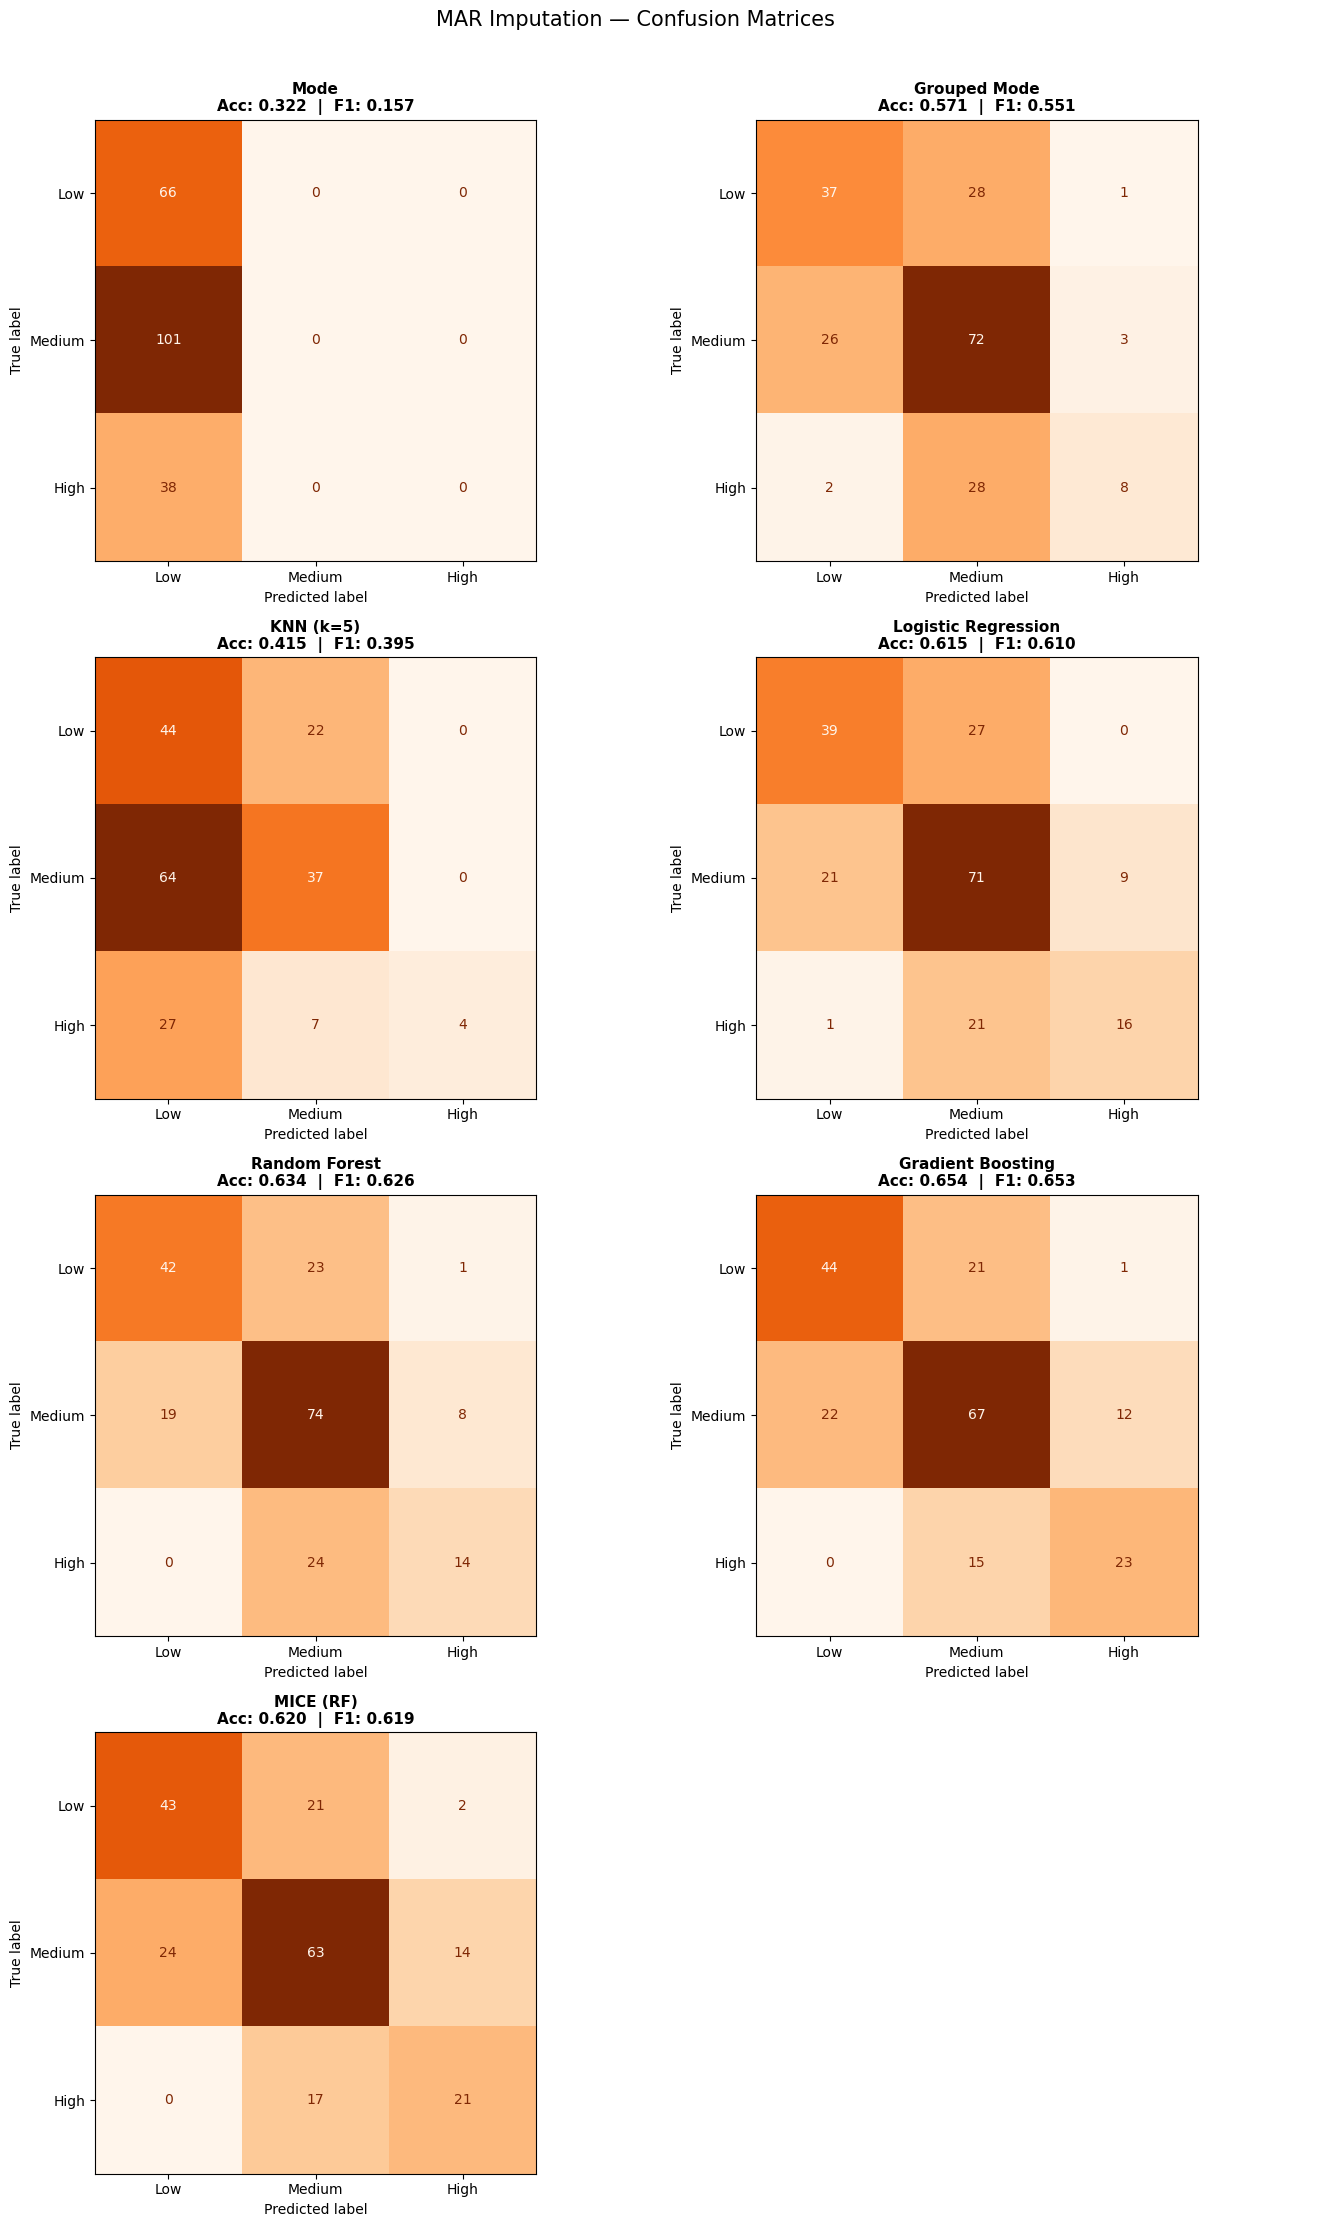

In [34]:
# --- Confusion matrices ---
fig, axes = plt.subplots(4, 2, figsize=(14, 22))
axes = axes.flatten()
labels = ['Low', 'Medium', 'High']

for ax, (name, cm) in zip(axes, confusion_matrices_mar.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap='Oranges')   # orange to visually distinguish from MCAR
    row = results_mar[results_mar['Method'] == name].iloc[0]
    ax.set_title(f"{name}\nAcc: {row['Accuracy']:.3f}  |  F1: {row['F1 (weighted)']:.3f}",
                 fontsize=11, fontweight='bold')

axes[-1].axis('off')
plt.suptitle('MAR Imputation — Confusion Matrices', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [35]:
comparison = results_df[['Method', 'F1 (weighted)']].rename(
                columns={'F1 (weighted)': 'MCAR'}
             ).merge(
                results_mar[['Method', 'F1 (weighted)']].rename(
                columns={'F1 (weighted)': 'MAR'}),
             on='Method')
print("\n=== MCAR vs MAR ===")
print(comparison.round(4).to_string(index=False))


=== MCAR vs MAR ===
             Method   MCAR    MAR
      Random Forest 0.7153 0.6265
  Gradient Boosting 0.6999 0.6535
          MICE (RF) 0.6545 0.6193
       Grouped Mode 0.6436 0.5510
Logistic Regression 0.6042 0.6099
          KNN (k=5) 0.4497 0.3946
               Mode 0.2535 0.1568


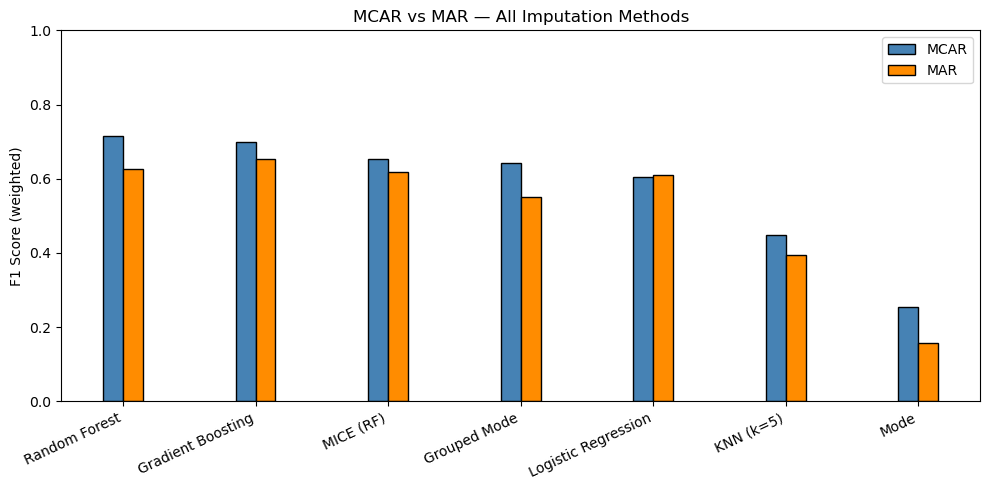

In [38]:
# --- Visual comparison ---
x = np.arange(len(comparison))
width = 0.15

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, comparison['MCAR'], width, label='MCAR',
               color='steelblue', edgecolor='k')
bars2 = ax.bar(x + width/2, comparison['MAR'],  width, label='MAR',
               color='darkorange', edgecolor='k')

ax.set_xticks(x)
ax.set_xticklabels(comparison['Method'], rotation=25, ha='right')
ax.set_ylabel('F1 Score (weighted)')
ax.set_title('MCAR vs MAR — All Imputation Methods')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()